In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

Se cargan los datos que se han preparado en el notebook de preprocessing

In [18]:
X = pd.read_csv('X_procesado.csv')
y = pd.read_csv('y_procesado.csv').squeeze()

Se divide el dataset en datos de entrenamiento y datos de test.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print(X_train.shape)
print(X_test.shape)

(39073, 50)
(9769, 50)


In [21]:
print(X_train.shape)
print(X_test.shape)

(39073, 50)
(9769, 50)



Antes de entrenar los modelos se comprueba que no queden variables categóricas sin codificar.

In [22]:
X.select_dtypes(include='object').columns

Index([], dtype='str')

In [23]:

if len(X.select_dtypes(include='object').columns) > 0:
    X = pd.get_dummies(
        X,
        columns=X.select_dtypes(include='object').columns,
        drop_first=True
    )

In [24]:

X = X.astype(int)

In [25]:
y.unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

In [26]:
if y.dtype == 'object':
    y = y.map({
        '<=50K': 0,
        '>50K': 1
    })

In [32]:
y.value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [33]:
y.unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

Se crea una función para evaluar todos los modelos con las mismas métricas.

In [27]:
resultados_modelos = []

In [35]:
#ia
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='>50K')
    recall = recall_score(y_test, y_pred, pos_label='>50K')
    f1 = f1_score(y_test, y_pred, pos_label='>50K')
    roc_auc = roc_auc_score(y_test, y_proba)

    resultados_modelos.append([
        nombre_modelo,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print(nombre_modelo)
    print("-" * 40)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    matriz = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(matriz, annot=True, fmt='d')
    plt.title(f'Matriz de confusión - {nombre_modelo}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

entrenamos un Random Forest sin ajustar hiperparámetros.

In [29]:
rf_baseline = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [30]:
rf_baseline.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

Random Forest Baseline
----------------------------------------
Accuracy: 0.8624
Precision: 0.7544
Recall: 0.6305
F1-score: 0.6869
ROC-AUC: 0.9101

Classification report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.75      0.63      0.69      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



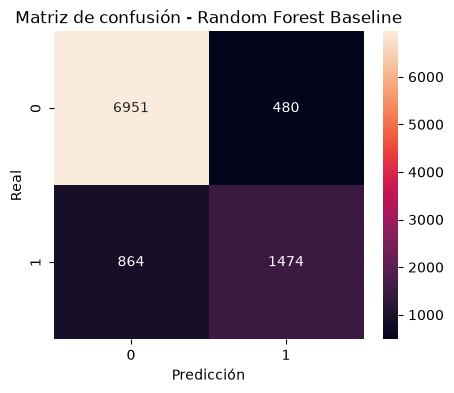

In [36]:
evaluar_modelo(
    'Random Forest Baseline',
    rf_baseline,
    X_test,
    y_test
)

Se utiliza validación cruzada para comprobar si el modelo es estable.

In [37]:
cv_rf_baseline = cross_val_score(
    rf_baseline,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

print("F1 medio CV:", round(cv_rf_baseline.mean(), 4))
print("Desviación CV:", round(cv_rf_baseline.std(), 4))

F1 medio CV: 0.8514
Desviación CV: 0.0022


hora se ajustan algunos hiperparámetros para intentar mejorar el modelo.

In [38]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [39]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [40]:
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_rf,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [41]:
random_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function

In [42]:
random_search_rf.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [43]:
rf_tuned = random_search_rf.best_estimator_

Random Forest Tuned
----------------------------------------
Accuracy: 0.8699
Precision: 0.7888
Recall: 0.6232
F1-score: 0.6963
ROC-AUC: 0.9196

Classification report:
              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      7431
        >50K       0.79      0.62      0.70      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.86      0.87      0.86      9769



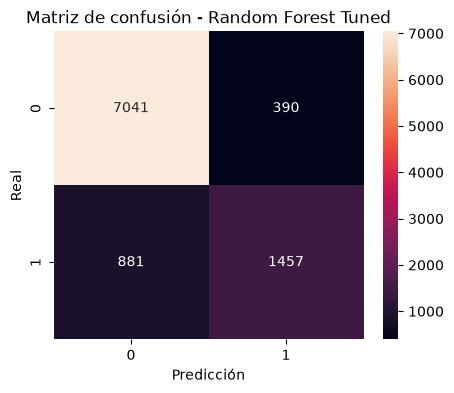

In [44]:
evaluar_modelo(
    'Random Forest Tuned',
    rf_tuned,
    X_test,
    y_test
)

ahora despues del random forest entrenamos un modelo LightGBM con los parámetros por defecto.

In [45]:
lgbm_baseline = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [46]:
lgbm_baseline.fit(X_train, y_train)

,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


LightGBM Baseline
----------------------------------------
Accuracy: 0.877
Precision: 0.7925
Recall: 0.6583
F1-score: 0.7192
ROC-AUC: 0.9295

Classification report:
              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      7431
        >50K       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



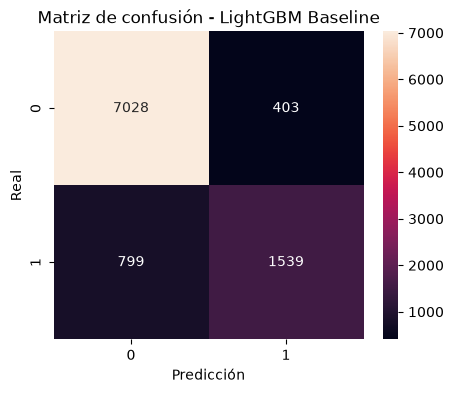

In [47]:
evaluar_modelo(
    'LightGBM Baseline',
    lgbm_baseline,
    X_test,
    y_test
)

Se comprueba el rendimiento del modelo usando otra vez la validación cruzada.

In [48]:
cv_lgbm_baseline = cross_val_score(
    lgbm_baseline,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

print("F1 medio CV:", round(cv_lgbm_baseline.mean(), 4))
print("Desviación CV:", round(cv_lgbm_baseline.std(), 4))

F1 medio CV: 0.8696
Desviación CV: 0.0045


realizamos una búsqueda de hiperparámetros para mejorar el modelo.

In [49]:
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10, 15],
    'num_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [50]:
lgbm = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [51]:
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_lgbm,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [52]:
random_search_lgbm.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function 

In [53]:
random_search_lgbm.best_params_

{'subsample': 0.8,
 'num_leaves': 15,
 'n_estimators': 100,
 'max_depth': 15,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [54]:
lgbm_tuned = random_search_lgbm.best_estimator_

LightGBM Tuned
----------------------------------------
Accuracy: 0.8759
Precision: 0.7945
Recall: 0.6497
F1-score: 0.7148
ROC-AUC: 0.9289

Classification report:
              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      7431
        >50K       0.79      0.65      0.71      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



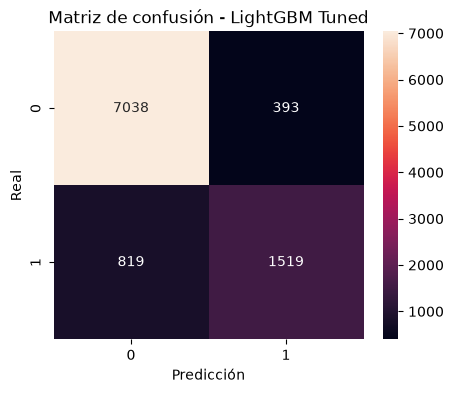

In [55]:
evaluar_modelo(
    'LightGBM Tuned',
    lgbm_tuned,
    X_test,
    y_test
)

ahora comparamos los 2 los modelos entrenados

In [56]:
resultados_df = pd.DataFrame(
    resultados_modelos,
    columns=[
        'Modelo',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC'
    ]
)

resultados_df.sort_values('F1-score', ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,LightGBM Baseline,0.876958,0.792482,0.658255,0.719159,0.929484
3,LightGBM Tuned,0.875934,0.794456,0.649701,0.714824,0.928857
1,Random Forest Tuned,0.869895,0.788847,0.623182,0.696296,0.919563
0,Random Forest Baseline,0.862422,0.754350,0.630453,0.686859,0.910098


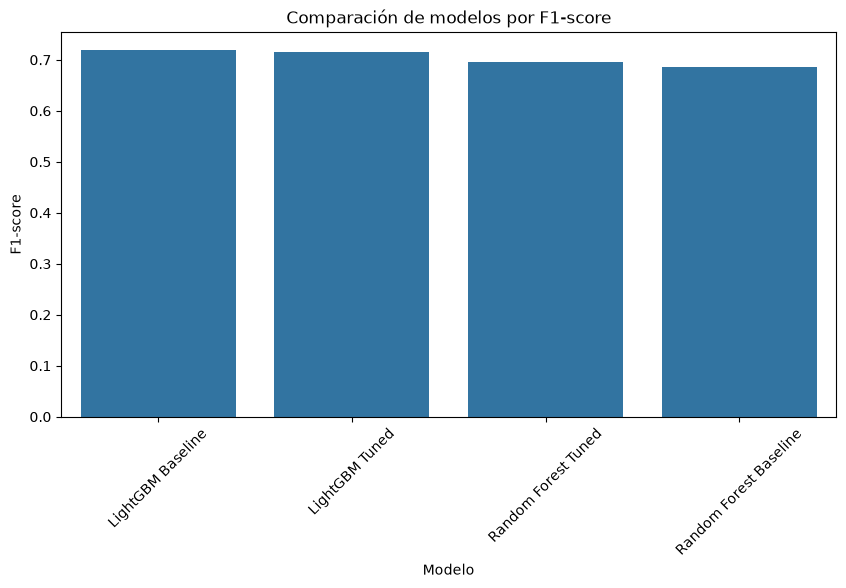

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=resultados_df.sort_values('F1-score', ascending=False),
    x='Modelo',
    y='F1-score'
)

plt.title('Comparación de modelos por F1-score')
plt.xticks(rotation=45)
plt.show()


Después de entrenar y comparar los diferentes modelos, se observa que LightGBM obtiene los mejores resultados generales.
El modelo que mejor rendimiento ha conseguido ha sido LightGBM Baseline, con un accuracy de 0.877, un F1-score de 0.719 y un ROC-AUC de 0.929. Aunque también se probó una versión ajustada mediante búsqueda de hiperparámetros, la mejora no fue significativa e incluso obtuvo resultados ligeramente inferiores.
En el caso de Random Forest, el ajuste de hiperparámetros sí permitió mejorar algo el rendimiento respecto al modelo baseline, aunque ambos quedaron por debajo de LightGBM.
En general, todos los modelos han mostrado una buena capacidad para clasificar correctamente los ingresos, ya que todos presentan valores de ROC-AUC superiores a 0.91.
Por tanto, el modelo seleccionado como modelo final es LightGBM Baseline, al ser el que obtiene las mejores métricas manteniendo además una configuración más sencilla.

y ahora para averiguar que variables tienen mas importancia 

In [60]:
mejor_modelo = lgbm_baseline

In [61]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': mejor_modelo.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

importancias.head(15)

,Variable,Importancia
0,age,520
1,fnlwgt,399
4,capital-gain,342
5,capital-loss,315
6,hours-per-week,257
2,educational-num,237
17,marital-status_Married-civ-spouse,82
12,workclass_Self-emp-not-inc,65
24,occupation_Exec-managerial,62
3,gender,54


aqui podemos ver claramente que la variable que mas importancia tiene es age seguido de fnlwgt y de capital gain. 